# Importing required libraries

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Loading the model

In [28]:
data = pd.read_csv("../Datasets/employee_churn.csv")
data = data.dropna()  

data

,avg_monthly_hrs,department,filed_complaint,last_evaluation,n_projects,recently_promoted,salary,satisfaction,status,tenure
512,220,sales,1.0,0.940621,4,1.0,medium,0.647586,Employed,3.0
971,263,engineering,1.0,0.611552,4,1.0,medium,0.739768,Employed,2.0
1032,132,engineering,1.0,0.358521,5,1.0,low,0.509522,Employed,6.0
1150,245,sales,1.0,0.908024,2,1.0,medium,0.689759,Employed,2.0
1301,160,sales,1.0,0.495390,2,1.0,low,0.513384,Left,3.0
1834,245,sales,1.0,0.860953,2,1.0,medium,0.655321,Employed,2.0
1911,245,engineering,1.0,0.807585,4,1.0,low,0.662989,Employed,3.0
2286,217,procurement,1.0,0.881621,6,1.0,medium,0.667314,Employed,4.0
2582,262,management,1.0,0.803200,3,1.0,high,0.746154,Employed,7.0
2600,166,management,1.0,0.960392,3,1.0,high,0.693679,Employed,3.0


# Encoding the labels

In [29]:
encoder = LabelEncoder()
for i in data.columns:
    data[i] = encoder.fit_transform(data[i])

data    


,avg_monthly_hrs,department,filed_complaint,last_evaluation,n_projects,recently_promoted,salary,satisfaction,status,tenure
512,16,6,0,49,2,0,2,29,0,1
971,28,0,0,22,2,0,2,39,0,0
1032,1,0,0,1,3,0,1,12,0,4
1150,22,6,0,47,0,0,2,35,0,0
1301,6,6,0,12,0,0,1,13,1,1
1834,22,6,0,40,0,0,2,31,0,0
1911,22,0,0,30,2,0,1,33,0,1
2286,15,5,0,43,4,0,2,34,0,2
2582,27,3,0,29,1,0,0,41,0,5
2600,7,3,0,51,1,0,0,36,0,1


# Splitting into X & Y 

In [30]:
X = data.drop(columns = ['status'],axis = 1)
Y = data['status']

# Splitting for training and testing

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2 ,random_state = 42)

# Loading the model

In [32]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

# Making predictions

In [33]:
y_pred = model.predict(X_test)

# Testing Accuracys

In [34]:
accuracy = accuracy_score(y_test,y_pred)
print(f" Accuracy is :: {accuracy}")

 Accuracy is :: 1.0


# Plotting

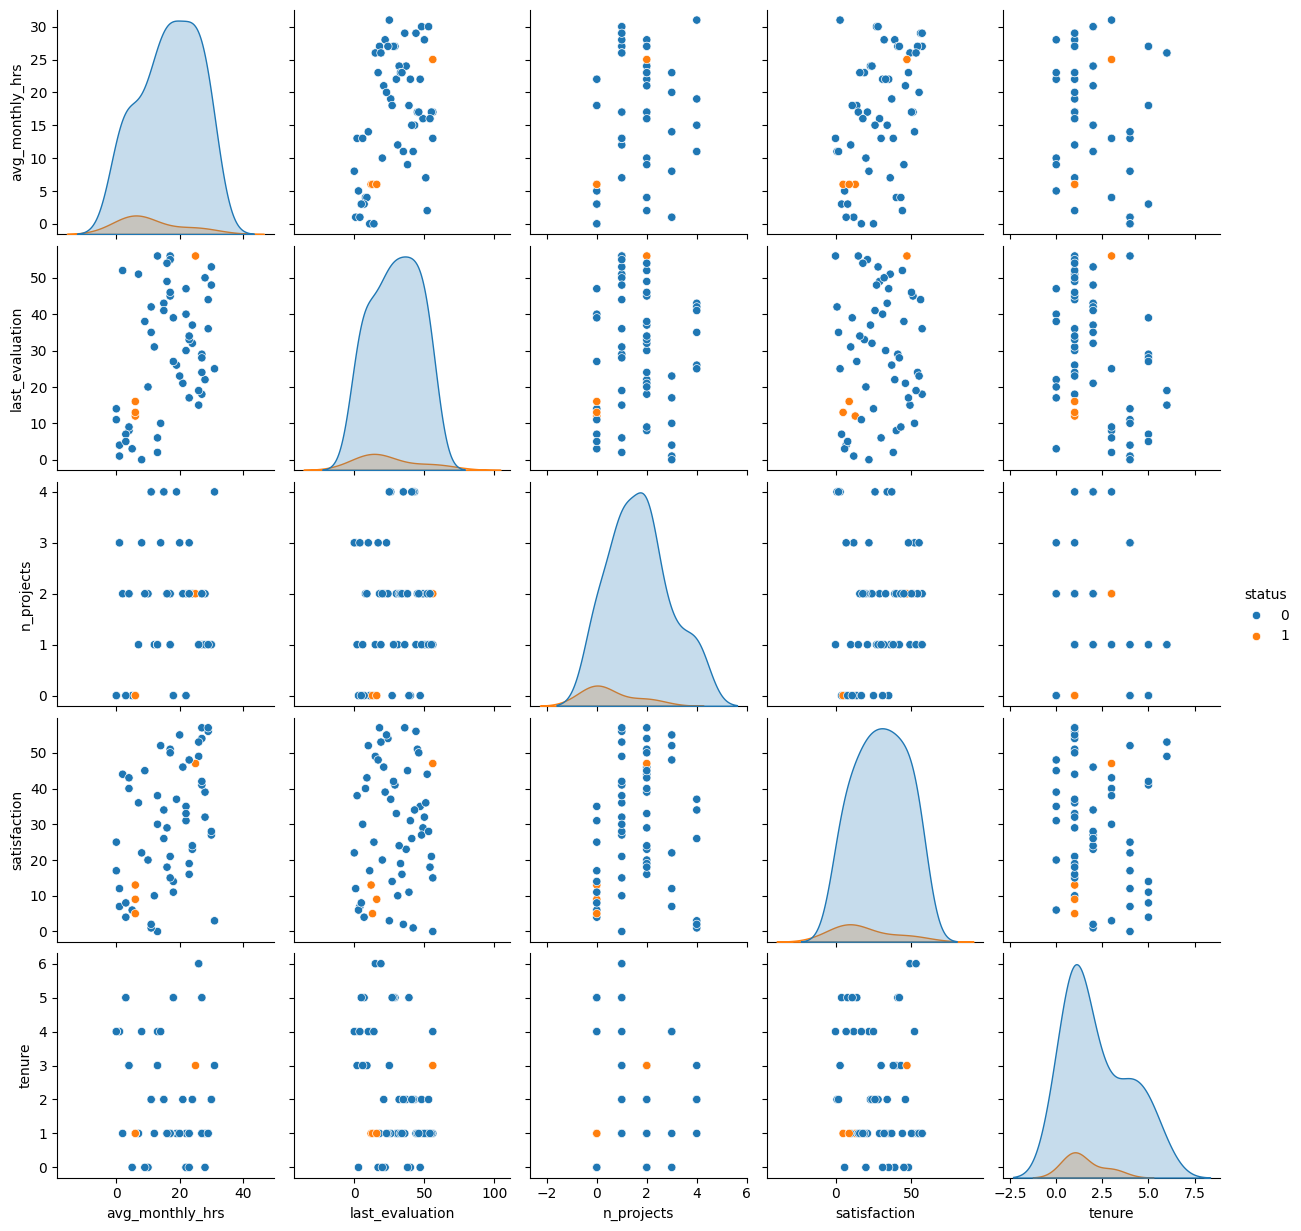

In [35]:
# Select numeric columns
selections = ['avg_monthly_hrs', 'last_evaluation', 'n_projects', 'satisfaction', 'tenure', 'status']

# Plot pairplot
sns.pairplot(data[selections], hue='status')
plt.show()